# Lab1_3

In [1]:
import numpy as np
import pylab as p
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D





#Exercise1: finite-differences with tolerance **Jacobi method**

SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0




In [2]:
#V_i → condiciones de frontera ; Nmax → division de la malla ; Niter → iterations over algorithm

def Laplace2D(V_i , Nmax, Niter,tol,x,y,condicion):

  V = V_i
  i=0
  for iter in range(Niter):
    V_prev = V.copy()
    for i in range(1, Nmax-2):
      for j in range(1,Nmax-2):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
    i+=1
    # Tolerancia
    err = np.max(np.abs(V - V_prev))

    if err < tol:
      if condicion == "T":
        print(i)
      break

  X, Y = np.meshgrid(x,y)
  Z = V[X,Y]

  return X, Y ,Z

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).

Veamos las graficas que encontramos en funcion de las tolerancia que usemos en este rango.

In [3]:
L , Niter  = 100, 1000
tol = np.array([10e-5, 10e-4,10e-3,10e-2])

x = np.arange(0,L,1)
y = x

V_i = np.zeros((L,L))
for k in range(0, L-1): V_i[k,0] = 100.0

for n in range(len(tol)):
    X, Y, Z = Laplace2D(V_i, L, Niter, tol[n], x, y,"F")

    globals()[f"X{n+1}"] = X
    globals()[f"Y{n+1}"] = Y
    globals()[f"Z{n+1}"] = Z

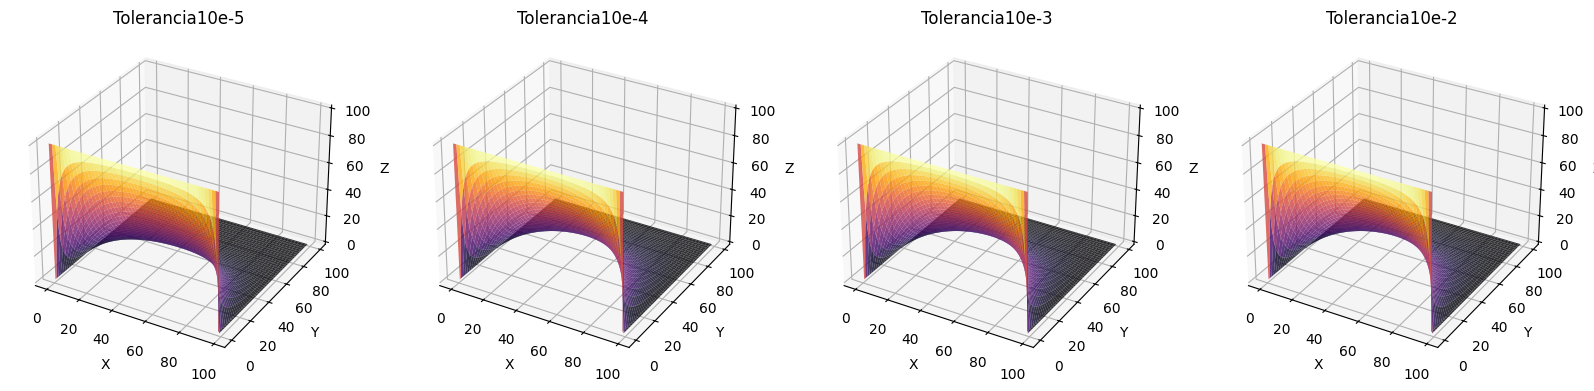

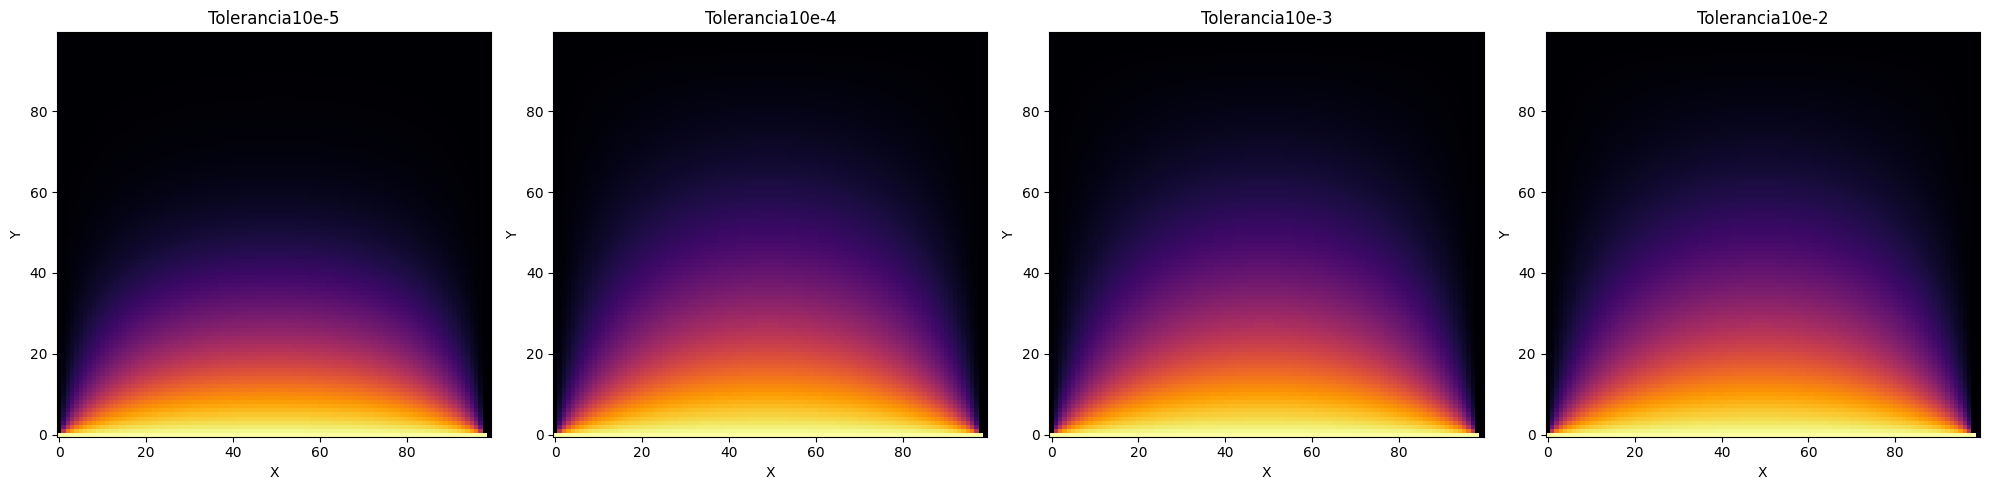

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    X = globals()[f"X{i+1}"]
    Y = globals()[f"Y{i+1}"]
    Z = globals()[f"Z{i+1}"]

    surf = ax.plot_surface(X, Y, Z, cmap='inferno', alpha=0.8)

    ax.set_title(f"Tolerancia10e{i-5}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")


fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, ax in enumerate(axes):
    X = globals()[f"X{i+1}"]
    Y = globals()[f"Y{i+1}"]
    Z = globals()[f"Z{i+1}"]


    c = ax.pcolormesh(X, Y, Z, cmap='inferno')

    ax.set_title(f"Tolerancia10e{i-5}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.tight_layout()
plt.show()



El rango de tolerancia es bastante bueno, pues nos muestra curvas o difuminados suaves.El modelo numerico converge adecuadamente. Sin embargo, podemos notar una grandes diferencias en cuanto a la eleccion de un nivel de tolerancia a otro. El "difuminado" correspondiente del potencial es mayor mientras la tolerancia es tambien mayor. Lo que implica que se debe realizar una buena eleccion de la misma para mantener una buena precision.

2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.


98


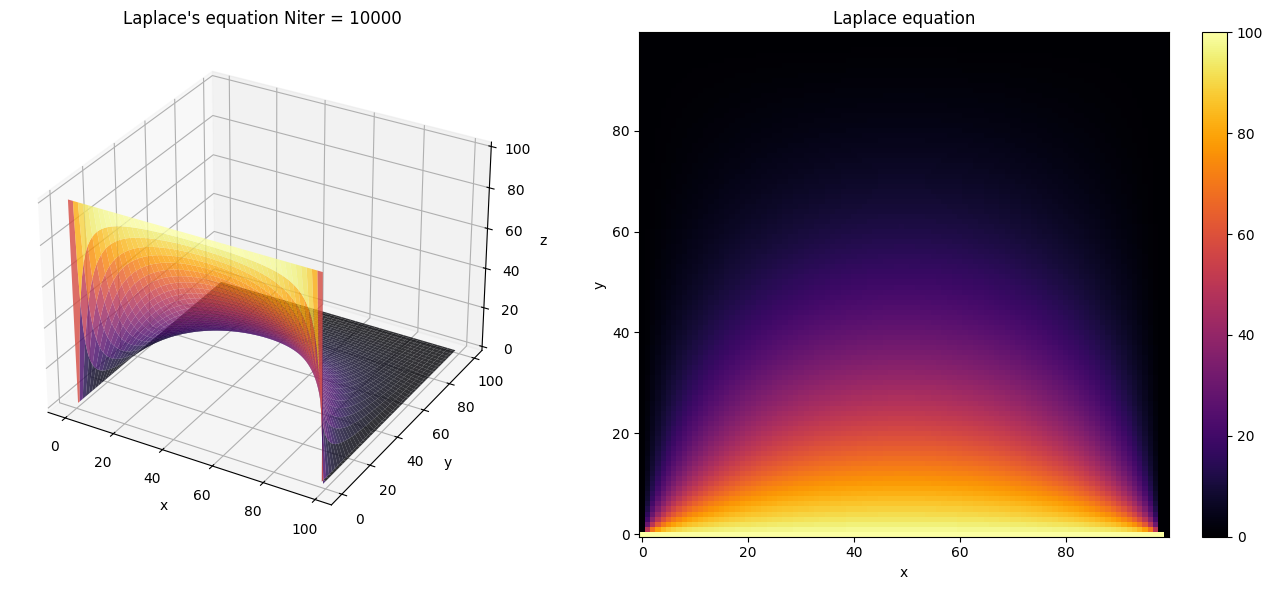

In [5]:
L , Niter, tol  = 100, 10000 , 10e-3
X, Y, Z = Laplace2D(V_i, L, Niter, tol, x, y, "T")


fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='inferno', alpha=0.8)

ax1.set_title(f"Laplace's equation Niter = {Niter}")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')


ax2 = fig.add_subplot(1, 2, 2)
c = ax2.pcolormesh(X, Y, Z, cmap='inferno')

ax2.set_title('Laplace equation')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

fig.colorbar(c, ax=ax2)
plt.tight_layout()
plt.show()

La estrategia consistio en medir la diferencia entre el valor de la funcion dada por el metodo en la iteracion "actual" n y la iteracion anterior n-1. El valor de la tolerancia es aquel que se considera la diferencia "adecuada" para obtener un nivel de precision adecuado en la solucion de la ecuacion PDE.

3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.


In [6]:
L , Niter, tol  = 100, 1000 , 10e-3

U_numerica = np.zeros((L,L))
for k in range(0, L-1): U_numerica[k,0] = 100.0 # line at 100V

count =0
for iter in range(10000):
  U_prev = U_numerica.copy()
  for i in range(1,L-2):
    for j in range(1,L-2):
      U_numerica[i,j] = 0.25*( U_numerica[i+1,j]+ U_numerica[i-1,j]+ U_numerica[i,j+1]+ U_numerica[i,j-1])
  count += 1
    # Tolerancia
  err = np.max(np.abs(U_numerica - U_prev))
  if err < tol:
    break

In [7]:
print(f"""La solucion numerica llega a la tolerancia en {count} iteraciones""")

La solucion numerica llega a la tolerancia en 1438 iteraciones


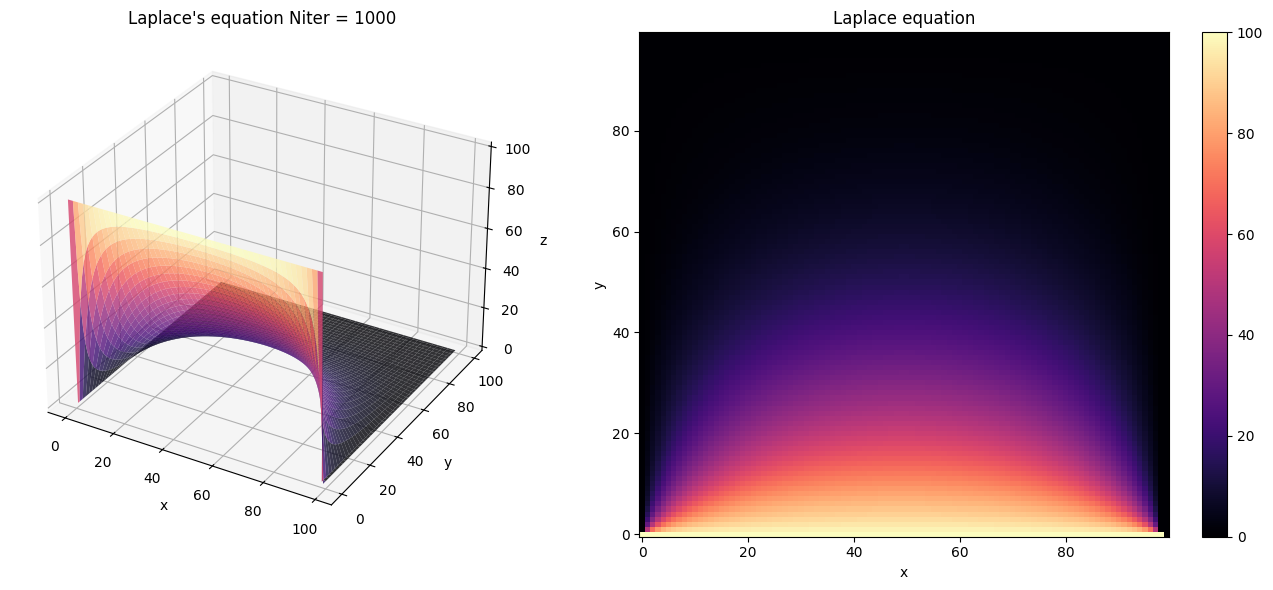

In [8]:
X, Y = np.meshgrid(x,y)
U_numerica = U_numerica[X,Y]

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, U_numerica, cmap='magma', alpha=0.8)

ax1.set_title(f"Laplace's equation Niter = {Niter}")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')


ax2 = fig.add_subplot(1, 2, 2)
c = ax2.pcolormesh(X, Y, U_numerica, cmap='magma')

ax2.set_title('Laplace equation')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

fig.colorbar(c, ax=ax2)
plt.tight_layout()
plt.show()

La solucion analitica:

$ u(x,y) = \sum_{n=1}^\infty \frac{4 V_0}{n \pi \sinh\big(n \pi\big)} \sin\left(\frac{n \pi}{L} x\right) \sinh\left(\frac{n  \pi}{L} (L - y)\right) $

con n impar

In [9]:
V0 , L , tol = 100, 100 , 10e-3

U_analitica = np.zeros((L,L))

x = np.arange(0,L,1)
y = x
X , Y = np.meshgrid(x,y)

i , n = 0 , 1 #i iteraciones , n terminos en la sumatoria
while True:
  #print(i,n)  #i = 57 entonces n=115 generan error en la funcion seno hiperbolico np.pi
  #U_analitica += (4*V0/(n*np.pi))*np.sin(n*np.pi*X/L)*np.sinh(n*np.pi*(L-Y)/L)/np.sinh(n*np.pi)    #presenta problema en el seno hiperbolico
  if i<57:
    U_analitica += (4*V0/(n*np.pi))*np.sin(n*np.pi*X/L)*np.sinh(n*np.pi*(L-Y)/L)/np.sinh(n*np.pi)    #presenta problema en el seno hiperbolico
    i +=1
    n +=2
  #print(U_analitica)
  err = np.max(np.abs(U_analitica - U_prev))
  if err < tol:
    break

  if i >=57:   #correccion del problema
   a = n*np.pi*(L - Y)/L
   b = n*np.pi
   sinh_ratio = (np.exp(a - b) - np.exp(-(a + b))) / (1 - np.exp(-2*b))
   U_analitica += (4*V0/(n*np.pi)) * np.sin(n*np.pi*X/L) * sinh_ratio
   i +=1
   n +=2

  err = np.max(np.abs(U_analitica - U_prev))
  if err < tol:
    break
  U_prev = U_analitica.copy()



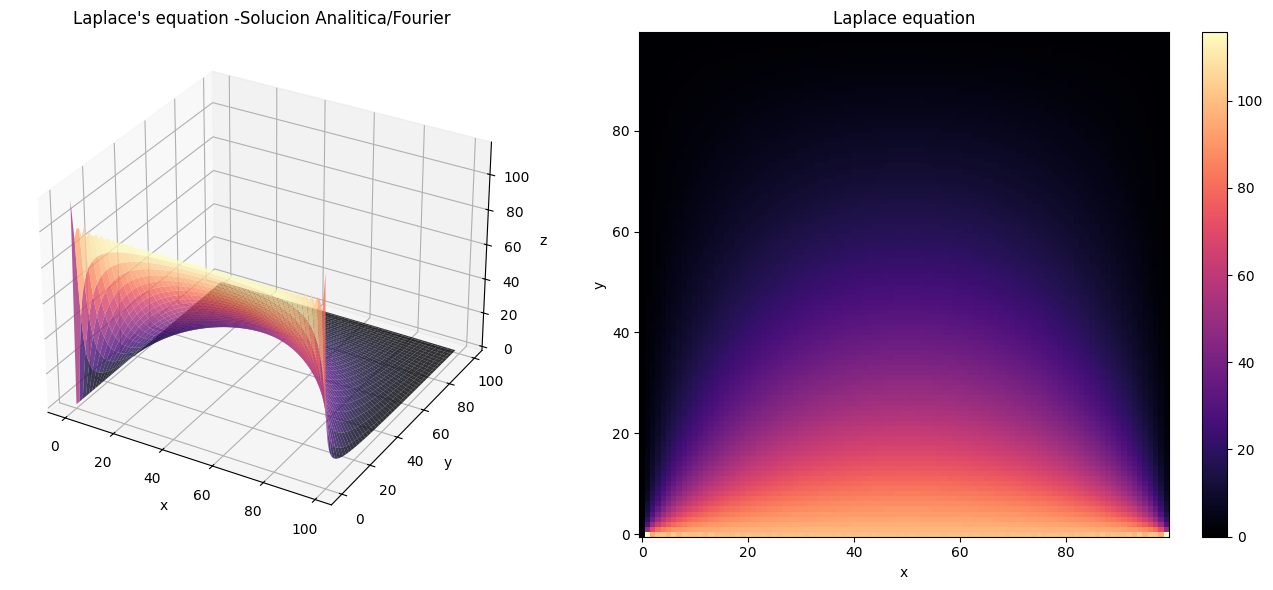

In [10]:
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, U_analitica, cmap='magma', alpha=0.8)

ax1.set_title(f"Laplace's equation -Solucion Analitica/Fourier")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')


ax2 = fig.add_subplot(1, 2, 2)
c = ax2.pcolormesh(X, Y, U_analitica, cmap='magma')

ax2.set_title('Laplace equation')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

fig.colorbar(c, ax=ax2)
plt.tight_layout()
plt.show()

In [11]:
print(f"""La solucion analitica llega a la tolerancia en {i} iteraciones""")

La solucion analitica llega a la tolerancia en 58 iteraciones


In [12]:
print(f"""las iteraciones dadas por la solucion numerica, en diferencias finitas, fueron {count} ,
 las iteracioones en la serie de fourier, la solucion analitica, fueron {i}""")

las iteraciones dadas por la solucion numerica, en diferencias finitas, fueron 1438 ,
 las iteracioones en la serie de fourier, la solucion analitica, fueron 58


Observamos que la serie de fourier converge mas rapido en la tolerancia de 10e-3 que el metodo numerico usado en la solucion de la ecuacion diferencial de laplace.

# **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

Solucion Numerica

In [13]:
def Laplace2D_rect(V_i , i_max,j_max, Niter,tol,x,y): #se debe modificar la funcion para un rectangulo

  V = V_i

  for iter in range(Niter):
    V_prev = V.copy()
    for i in range(1, i_max-2):
      for j in range(1,j_max-2):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

    # Tolerancia
    err = np.max(np.abs(V - V_prev))
    if err < tol:
      break

  X, Y = np.meshgrid(x,y)
  Z = V[X,Y]

  return X, Y ,Z

In [14]:
u0 , L , Niter, tol  = 100, 50 , 1000, 10e-3

x = np.arange(0,L,1)
y = np.arange(0,L*5,1)

In [15]:
V_i = np.zeros((len(x),len(y)))
for k in range(0, L-1): V_i[k,0] = u0*np.sin(2*np.pi*x[k]/L)
V_i

array([[  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [ 12.53332336,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [ 24.86898872,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [-36.81245527,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [-24.86898872,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

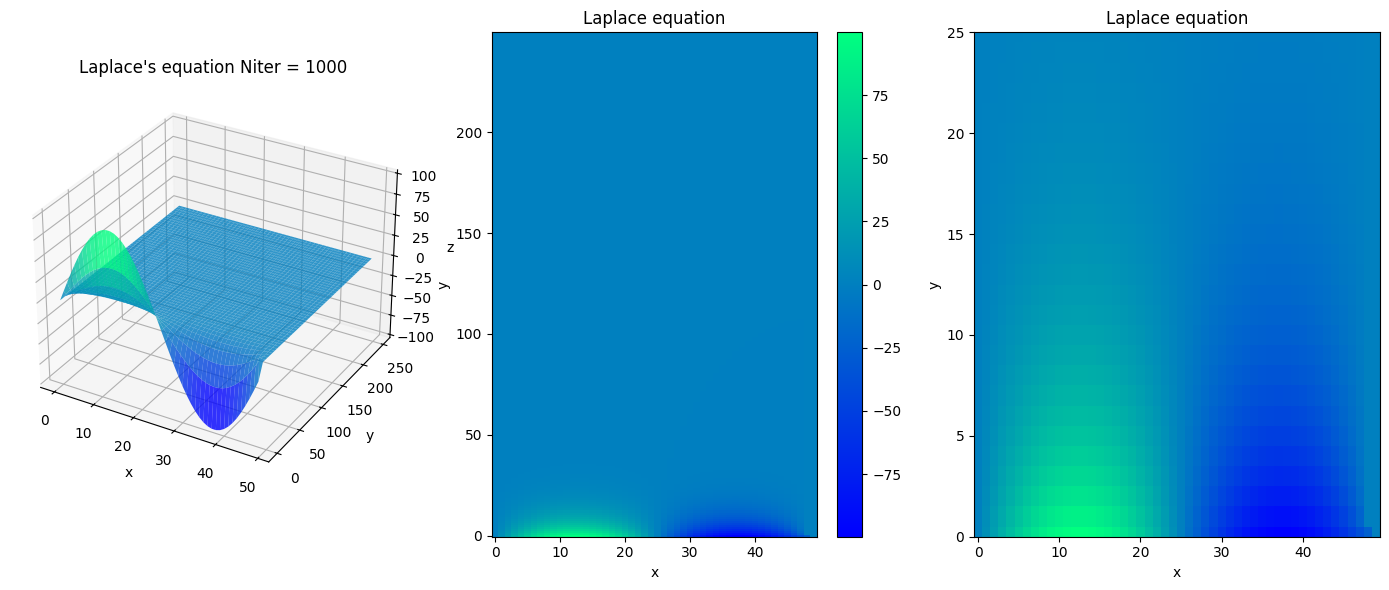

In [16]:
X, Y, Z =  Laplace2D_rect(V_i , L,L*5, Niter,tol,x,y)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='winter', alpha=0.8)
ax1.set_title(f"Laplace's equation Niter = {Niter}")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')


ax2 = fig.add_subplot(1, 3, 2)
c = ax2.pcolormesh(X, Y, Z, cmap='winter')
ax2.set_title('Laplace equation')
ax2.set_xlabel('x')
ax2.set_ylabel('y')


ax3 = fig.add_subplot(1, 3, 3)
c = ax3.pcolormesh(X, Y, Z, cmap='winter')

ax3.set_title('Laplace equation')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_ylim(0, L/2) #para visualizar mejor la propagacion

fig.colorbar(c, ax=ax2)
plt.tight_layout()
plt.show()

Solucion Analitica:

$
u(x,y) = u_0 \sin\left(\frac{2\pi x}{L}\right)\, e^{-\frac{2\pi y}{L}}
$

In [17]:
U_analitica = np.zeros((L,L*5))
V0 , L  = 100, 100

x = np.arange(0,L,1)
y = np.arange(0,L*5,1)

def funcion(x_,y_):
  k =(2*np.pi/L)
  return V0*np.sin(k*x_)*np.exp(-k*y_)

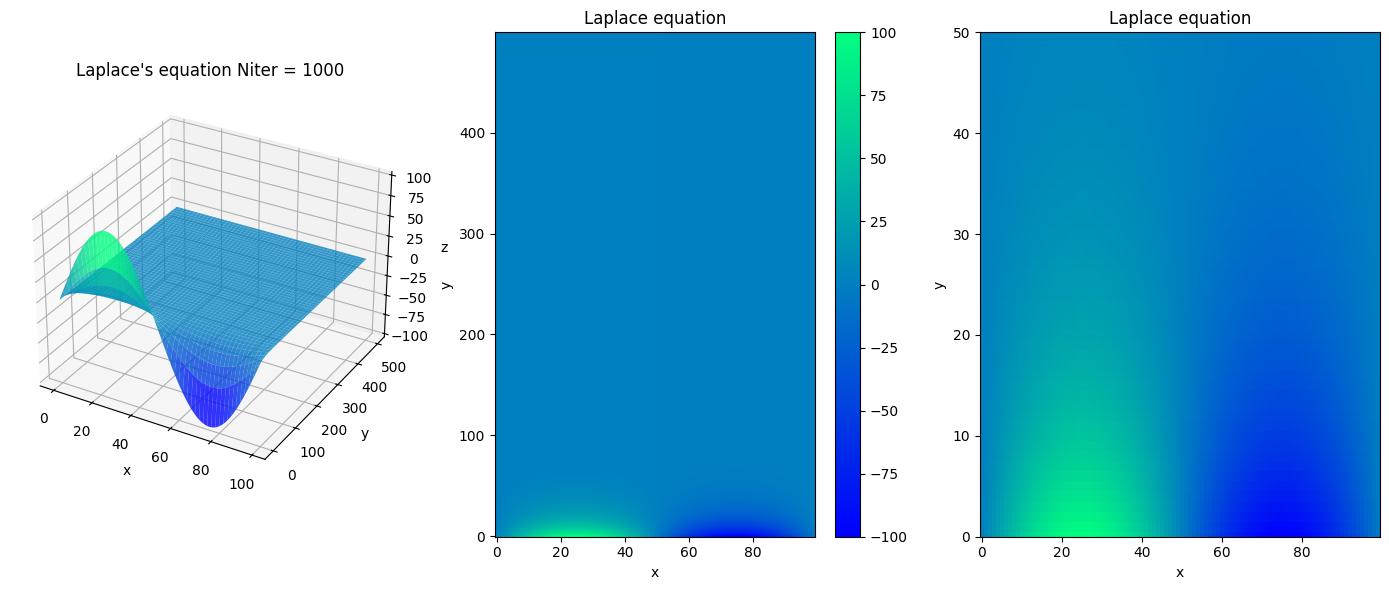

In [18]:
X, Y = np.meshgrid(x,y)
Z= funcion(X,Y)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='winter', alpha=0.8)
ax1.set_title(f"Laplace's equation Niter = {Niter}")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')


ax2 = fig.add_subplot(1, 3, 2)
c = ax2.pcolormesh(X, Y, Z, cmap='winter')
ax2.set_title('Laplace equation')
ax2.set_xlabel('x')
ax2.set_ylabel('y')


ax3 = fig.add_subplot(1, 3, 3)
c = ax3.pcolormesh(X, Y, Z, cmap='winter')

ax3.set_title('Laplace equation')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_ylim(0, L/2) #para visualizar mejor la propagacion

fig.colorbar(c, ax=ax2)
plt.tight_layout()
plt.show()


La solucion es identica en ambos.

Nota 4.0 Revisado... Entrega tarde. Quizás mal el git push!